In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report
)

In [2]:
def upload_dataset(path):
    train = pd.read_csv(f"./train_{path}.csv")
    test = pd.read_csv(f"./test_{path}.csv")
    
    y_train = train["Class"]
    y_test  = test["Class"]
    
    X_train = train.drop(columns=["Class"])
    X_test  = test.drop(columns=["Class"])

    return X_train, y_train, X_test, y_test
    
X_train, y_train, X_test, y_test = upload_dataset("final")
X_train_MI, _, X_test_MI, _ = upload_dataset("MI")
X_train_40, _, X_test_40, _ = upload_dataset("40")

all_classes = np.union1d(np.unique(y_train), np.unique(y_test))
label_map = {
    0: "Adware",
    1: "Banking",
    2: "SMS",
    3: "Riskware",
    4: "Benign"
}
CLASS_NAMES = [label_map.get(i, f'Class_{i}') for i in all_classes]

In [3]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}   Precision : {prec:.4f}   Recall : {rec:.4f}   Macro F1: {f1:.4f}')
    print(classification_report(y_true, y_pred,
                                labels=all_classes,
                                target_names=CLASS_NAMES))
    cm = confusion_matrix(y_true, y_pred, labels=all_classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show()
    return acc, prec, rec, f1

RESULTS = {}

## SVM

Training runtime: 16.546s
Prediction runtime: 8.740s

=== SVM (20) ===
Accuracy : 0.5428   Precision : 0.5855   Recall : 0.4361   Macro F1: 0.4234
              precision    recall  f1-score   support

      Adware       0.53      0.07      0.12       376
     Banking       0.63      0.16      0.26       613
         SMS       0.50      0.99      0.67      1171
    Riskware       0.62      0.34      0.43       760
      Benign       0.65      0.62      0.63       538

    accuracy                           0.54      3458
   macro avg       0.59      0.44      0.42      3458
weighted avg       0.58      0.54      0.48      3458



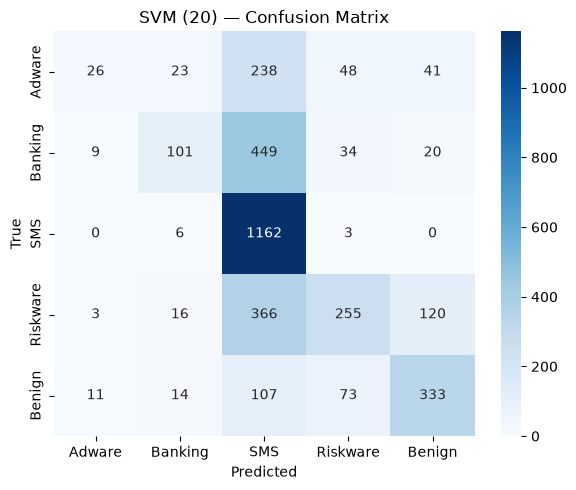

Training runtime: 18.282s
Prediction runtime: 9.067s

=== SVM (MI) ===
Accuracy : 0.4615   Precision : 0.6564   Recall : 0.3419   Macro F1: 0.3240
              precision    recall  f1-score   support

      Adware       0.79      0.04      0.08       376
     Banking       0.96      0.08      0.15       613
         SMS       0.43      0.94      0.59      1171
    Riskware       0.50      0.36      0.42       760
      Benign       0.60      0.29      0.39       538

    accuracy                           0.46      3458
   macro avg       0.66      0.34      0.32      3458
weighted avg       0.60      0.46      0.39      3458



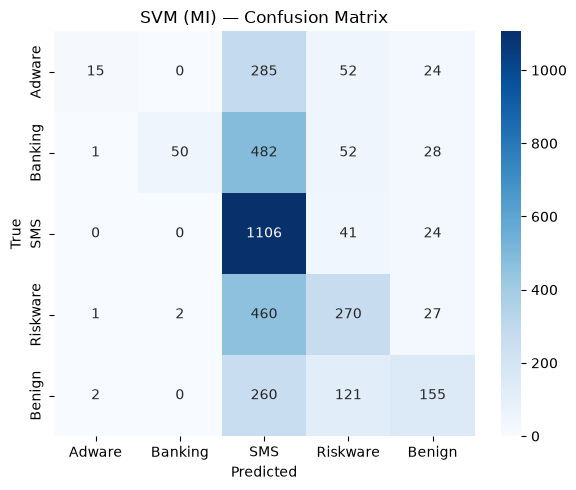

Training runtime: 11.030s
Prediction runtime: 8.846s

=== SVM (top-40) ===
Accuracy : 0.7169   Precision : 0.7047   Recall : 0.6404   Macro F1: 0.6524
              precision    recall  f1-score   support

      Adware       0.66      0.27      0.39       376
     Banking       0.68      0.57      0.62       613
         SMS       0.73      0.95      0.83      1171
    Riskware       0.71      0.71      0.71       760
      Benign       0.74      0.70      0.72       538

    accuracy                           0.72      3458
   macro avg       0.70      0.64      0.65      3458
weighted avg       0.71      0.72      0.70      3458



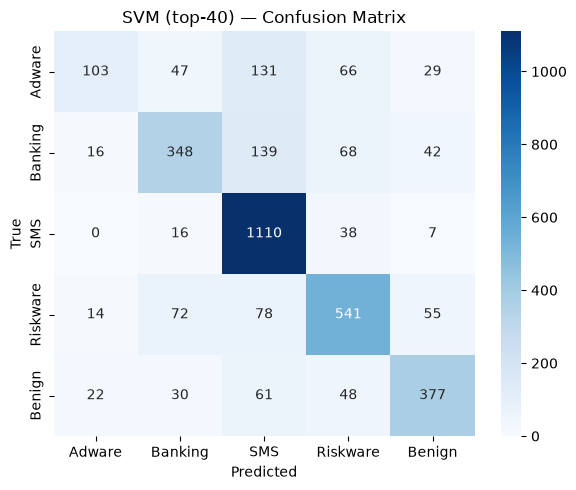

In [7]:
def SVM_train(name, X_train, X_test):
    svm= SVC(kernel='rbf', random_state=42)
    
    start = time.time()
    svm.fit(X_train, y_train)
    TrainTime= time.time() - start
    print(f"Training runtime: {TrainTime:.3f}s")
    
    start = time.time()
    y_pred_svm = svm.predict(X_test)
    PredictTime= time.time() - start
    print(f"Prediction runtime: {PredictTime:.3f}s")
    
    acc_svm, prec_svm, rec_svm, f1_svm = evaluate(name, y_test, y_pred_svm)
    RESULTS[name] = {'Accuracy': acc_svm, 'Macro F1': f1_svm, 'precision': prec_svm, 'Recall': rec_svm, 'Training runtime': f'{TrainTime:.3f}', 'Prediction runtime': f'{PredictTime:.3f}'}



SVM_train("SVM (20)", X_train, X_test)
SVM_train("SVM (MI)", X_train_MI, X_test_MI)
SVM_train("SVM (top-40)", X_train_40, X_test_40)

## MLP

Training runtime: 2.876s
Prediction runtime: 0.014s

=== MLP (20) ===
Accuracy : 0.7212   Precision : 0.6944   Recall : 0.6549   Macro F1: 0.6649
              precision    recall  f1-score   support

      Adware       0.56      0.45      0.50       376
     Banking       0.71      0.45      0.55       613
         SMS       0.77      0.96      0.86      1171
    Riskware       0.67      0.73      0.70       760
      Benign       0.76      0.68      0.72       538

    accuracy                           0.72      3458
   macro avg       0.69      0.65      0.66      3458
weighted avg       0.71      0.72      0.71      3458



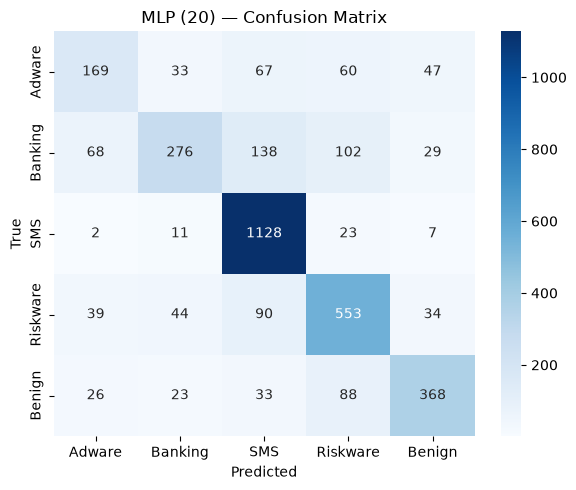

Training runtime: 20.533s
Prediction runtime: 0.017s

=== MLP (MI) ===
Accuracy : 0.7915   Precision : 0.7513   Recall : 0.7393   Macro F1: 0.7442
              precision    recall  f1-score   support

      Adware       0.53      0.49      0.51       376
     Banking       0.83      0.78      0.81       613
         SMS       0.87      0.97      0.92      1171
    Riskware       0.77      0.71      0.74       760
      Benign       0.75      0.74      0.75       538

    accuracy                           0.79      3458
   macro avg       0.75      0.74      0.74      3458
weighted avg       0.79      0.79      0.79      3458



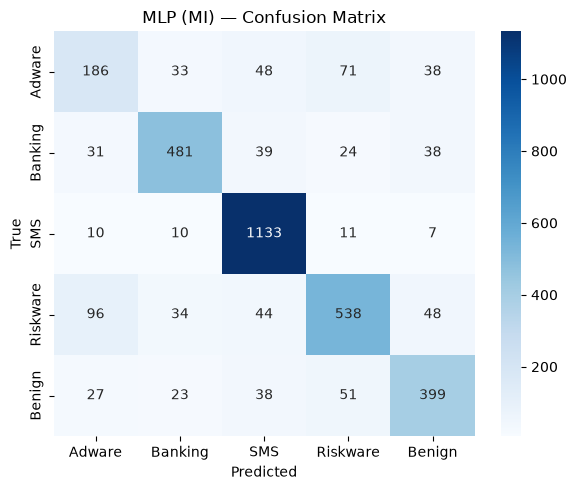

Training runtime: 312.163s
Prediction runtime: 0.077s

=== MLP (top-40) ===
Accuracy : 0.8814   Precision : 0.8650   Recall : 0.8550   Macro F1: 0.8594
              precision    recall  f1-score   support

      Adware       0.84      0.74      0.79       376
     Banking       0.84      0.84      0.84       613
         SMS       0.94      0.96      0.95      1171
    Riskware       0.87      0.88      0.88       760
      Benign       0.84      0.84      0.84       538

    accuracy                           0.88      3458
   macro avg       0.86      0.85      0.86      3458
weighted avg       0.88      0.88      0.88      3458



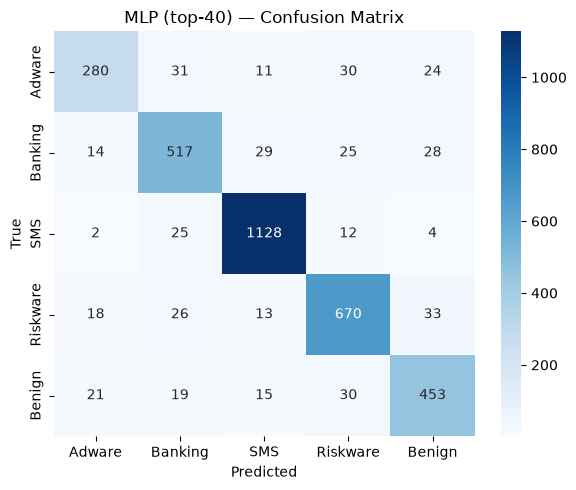

In [8]:
def MLP_train(name, X_train, X_test):
    mlp= MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000,random_state=42)
    
    start = time.time()
    mlp.fit(X_train, y_train)
    TrainTime= time.time() - start
    print(f"Training runtime: {TrainTime:.3f}s")
    
    start = time.time()
    y_pred_mlp = mlp.predict(X_test)
    PredictTime= time.time() - start
    print(f"Prediction runtime: {PredictTime:.3f}s")
    
    acc_mlp, prec_mlp, rec_mlp, f1_mlp = evaluate(name, y_test, y_pred_mlp)
    RESULTS[name] = {'Accuracy': acc_mlp, 'Macro F1': f1_mlp, 'precision': prec_mlp, 'Recall': rec_mlp, 'Training runtime': f'{TrainTime:.3f}', 'Prediction runtime': f'{PredictTime:.3f}'}

MLP_train("MLP (20)", X_train, X_test)
MLP_train("MLP (MI)", X_train_MI, X_test_MI)
MLP_train("MLP (top-40)", X_train_40, X_test_40)

## XGBoost

Training runtime: 3.023s
Prediction runtime: 0.052s

=== XGB (20) ===
Accuracy : 0.9283   Precision : 0.9139   Recall : 0.9121   Macro F1: 0.9129
              precision    recall  f1-score   support

      Adware       0.86      0.87      0.86       376
     Banking       0.91      0.90      0.90       613
         SMS       0.97      0.98      0.98      1171
    Riskware       0.93      0.93      0.93       760
      Benign       0.90      0.88      0.89       538

    accuracy                           0.93      3458
   macro avg       0.91      0.91      0.91      3458
weighted avg       0.93      0.93      0.93      3458



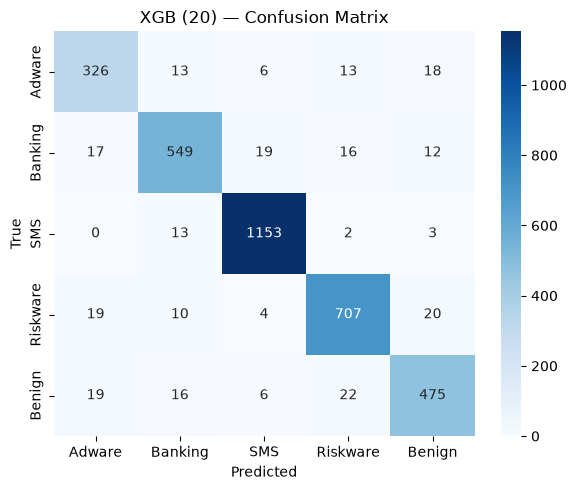

Training runtime: 6.577s
Prediction runtime: 0.052s

=== XGB (MI) ===
Accuracy : 0.9346   Precision : 0.9204   Recall : 0.9180   Macro F1: 0.9190
              precision    recall  f1-score   support

      Adware       0.86      0.87      0.87       376
     Banking       0.96      0.90      0.93       613
         SMS       0.98      0.99      0.99      1171
    Riskware       0.93      0.93      0.93       760
      Benign       0.88      0.90      0.89       538

    accuracy                           0.93      3458
   macro avg       0.92      0.92      0.92      3458
weighted avg       0.93      0.93      0.93      3458



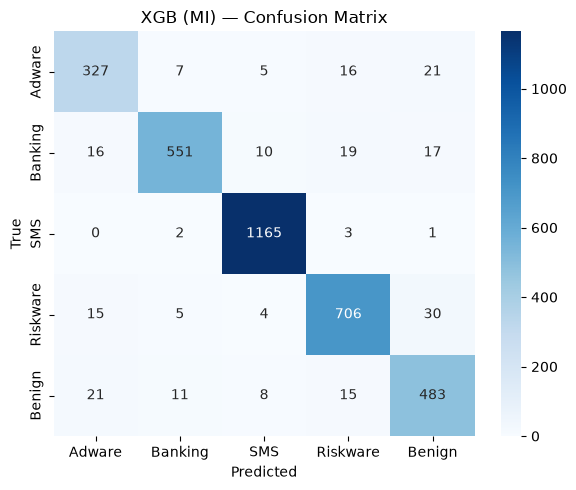

Training runtime: 7.481s
Prediction runtime: 0.041s

=== XGB (top-40) ===
Accuracy : 0.9265   Precision : 0.9132   Recall : 0.9102   Macro F1: 0.9116
              precision    recall  f1-score   support

      Adware       0.86      0.86      0.86       376
     Banking       0.92      0.90      0.91       613
         SMS       0.97      0.98      0.98      1171
    Riskware       0.91      0.93      0.92       760
      Benign       0.91      0.87      0.89       538

    accuracy                           0.93      3458
   macro avg       0.91      0.91      0.91      3458
weighted avg       0.93      0.93      0.93      3458



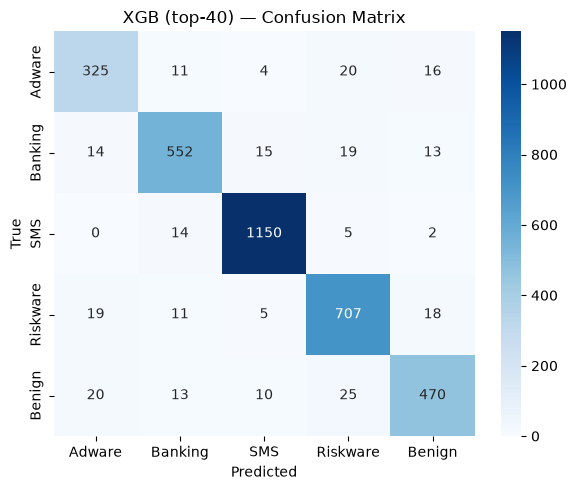

In [9]:
def XGB_train(name, X_train, X_test):
    xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
    
    start = time.time()
    xgb.fit(X_train, y_train)
    TrainTime= time.time() - start
    print(f"Training runtime: {TrainTime:.3f}s")
    
    start = time.time()
    y_pred_xgb = xgb.predict(X_test)
    PredictTime= time.time() - start
    print(f"Prediction runtime: {PredictTime:.3f}s")
    
    acc_xgb, prec_xgb, rec_xgb, f1_xgb = evaluate(name, y_test, y_pred_xgb)
    RESULTS[name] = {'Accuracy': acc_xgb, 'Macro F1': f1_xgb, 'precision': prec_xgb, 'Recall': rec_xgb, 'Training runtime': f'{TrainTime:.3f}', 'Prediction runtime': f'{PredictTime:.3f}'}

XGB_train("XGB (20)", X_train, X_test)
XGB_train("XGB (MI)", X_train_MI, X_test_MI)
XGB_train("XGB (top-40)", X_train_40, X_test_40)

# GridSearchCV

### SVM

Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearch time: 308.988s
Prediction runtime: 5.110s
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV macro-F1: 0.7604

=== SVM (GridSearchCV) ===
Accuracy : 0.7918   Precision : 0.7794   Recall : 0.7408   Macro F1: 0.7555
              precision    recall  f1-score   support

      Adware       0.72      0.55      0.62       376
     Banking       0.73      0.66      0.69       613
         SMS       0.80      0.97      0.88      1171
    Riskware       0.83      0.78      0.80       760
      Benign       0.81      0.75      0.78       538

    accuracy                           0.79      3458
   macro avg       0.78      0.74      0.76      3458
weighted avg       0.79      0.79      0.79      3458



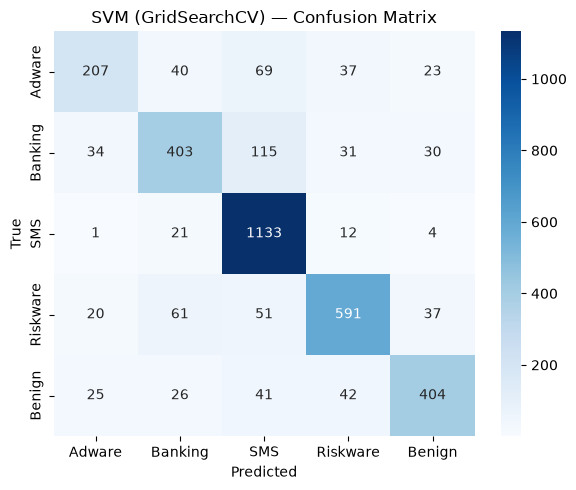

In [10]:
svm = SVC(random_state=42)

params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

GridSearch = GridSearchCV(
    estimator=svm,
    param_grid=params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

start = time.time()
GridSearch.fit(X_train_40, y_train)
GridSearchTime = time.time() - start
print(f"GridSearch time: {GridSearchTime:.3f}s")

start = time.time()
y_pred = GridSearch.predict(X_test_40)
PredictTime = time.time() - start
print(f"Prediction runtime: {PredictTime:.3f}s")

print(f'Best params: {GridSearch.best_params_}')
print(f"Best CV macro-F1: {GridSearch.best_score_:.4f}")

acc_svm, prec_svm, rec_svm, f1_svm = evaluate('SVM (GridSearchCV)', y_test, y_pred)
RESULTS['SVM (GridSearchCV)'] = {'Accuracy': acc_svm, 'Macro F1': f1_svm, 'precision': prec_svm, 'Recall': rec_svm, 'GridSearch runtime': f'{GridSearchTime:.3f}', 'Prediction runtime': f'{PredictTime:.3f}'}

### MLP

Fitting 5 folds for each of 36 candidates, totalling 180 fits
GridSearch time: 5331.364s
Prediction runtime: 0.092s
Best params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'max_iter': 800}
Best CV macro-F1: 0.8605

=== MLP (GridSearchCV) ===
Accuracy : 0.8962   Precision : 0.8808   Recall : 0.8688   Macro F1: 0.8743
              precision    recall  f1-score   support

      Adware       0.84      0.77      0.81       376
     Banking       0.88      0.85      0.86       613
         SMS       0.95      0.98      0.97      1171
    Riskware       0.87      0.90      0.89       760
      Benign       0.86      0.84      0.85       538

    accuracy                           0.90      3458
   macro avg       0.88      0.87      0.87      3458
weighted avg       0.89      0.90      0.90      3458



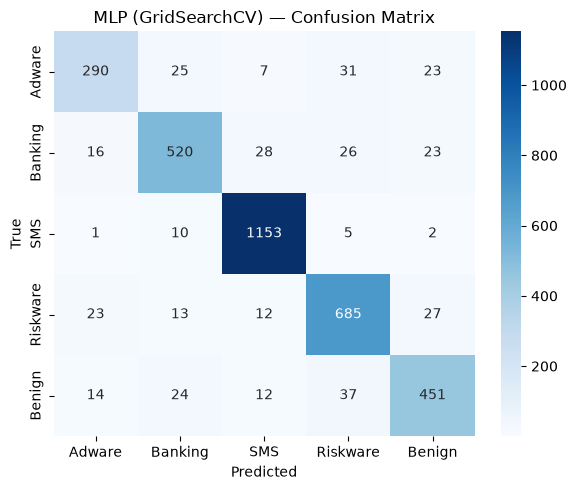

In [11]:
mlp= MLPClassifier( max_iter=1000,random_state=42)

params = {
            'hidden_layer_sizes': [(50,), (100,), (50, 50)],
            'max_iter': [500, 800, 1000],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001]
        }

GridSearch = GridSearchCV(
        estimator=mlp,
        param_grid=params,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2
    )

start = time.time()
GridSearch.fit(X_train_40, y_train)
GridSearchTime = time.time() - start
print(f"GridSearch time: {GridSearchTime:.3f}s")

start = time.time()
y_pred = GridSearch.predict(X_test_40)
PredictTime = time.time() - start
print(f"Prediction runtime: {PredictTime:.3f}s")

print(f'Best params: {GridSearch.best_params_}')
print(f"Best CV macro-F1: {GridSearch.best_score_:.4f}")

acc_mlp, prec_mlp, rec_mlp, f1_mlp = evaluate('MLP (GridSearchCV)', y_test, y_pred)
RESULTS['MLP (GridSearchCV)'] = {'Accuracy': acc_mlp, 'Macro F1': f1_mlp, 'precision': prec_mlp, 'Recall': rec_mlp, 'GridSearch runtime': f'{GridSearchTime:.3f}', 'Prediction runtime': f'{PredictTime:.3f}'}

### XGBoost

Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearch time: 146.359s
Prediction runtime: 0.042s
Best params: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200}
Best CV macro-F1: 0.9106

=== XGBoost (GridSearchCV) ===
Accuracy : 0.9271   Precision : 0.9113   Recall : 0.9111   Macro F1: 0.9111
              precision    recall  f1-score   support

      Adware       0.84      0.87      0.85       376
     Banking       0.92      0.90      0.91       613
         SMS       0.97      0.98      0.98      1171
    Riskware       0.93      0.93      0.93       760
      Benign       0.90      0.88      0.89       538

    accuracy                           0.93      3458
   macro avg       0.91      0.91      0.91      3458
weighted avg       0.93      0.93      0.93      3458



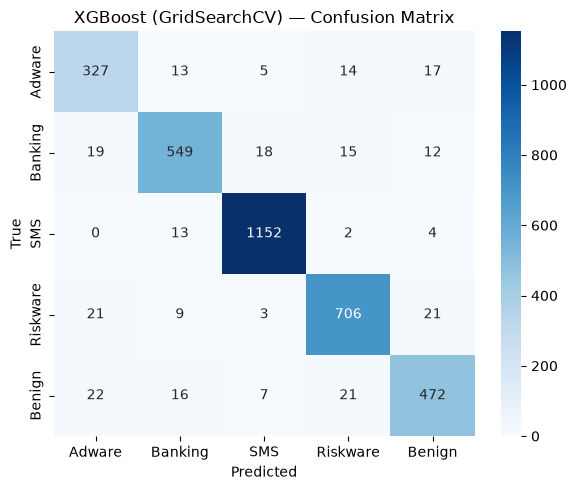

In [12]:
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

GridSearch = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

start = time.time()
GridSearch.fit(X_train, y_train)
GridSearchTime = time.time() - start
print(f"GridSearch time: {GridSearchTime:.3f}s")

start = time.time()
y_pred = GridSearch.predict(X_test)
PredictTime = time.time() - start
print(f"Prediction runtime: {PredictTime:.3f}s")

print(f'Best params: {GridSearch.best_params_}')
print(f"Best CV macro-F1: {GridSearch.best_score_:.4f}")

acc_xgb, prec_xgb, rec_xgb, f1_xgb = evaluate('XGBoost (GridSearchCV)', y_test, y_pred)
RESULTS['XGBoost (GridSearchCV)'] = {'Accuracy': acc_xgb, 'Macro F1': f1_xgb, 'precision': prec_xgb, 'Recall': rec_xgb, 'GridSearch runtime': f'{GridSearchTime:.3f}', 'Prediction runtime': f'{PredictTime:.3f}'}

## Results

=== Baseline Models ===
              Accuracy  Macro F1  precision    Recall  Training runtime  Prediction runtime
SVM (MI)      0.461538  0.324022   0.656410  0.341864            18.282               9.067
SVM (top-40)  0.716888  0.652437   0.704749  0.640426            11.030               8.846
SVM (20)      0.542799  0.423373   0.585517  0.436142            16.546               8.740
MLP (20)      0.721226  0.664928   0.694416  0.654928             2.876               0.014
MLP (MI)      0.791498  0.744220   0.751288  0.739285            20.533               0.017
MLP (top-40)  0.881434  0.859424   0.864972  0.854988           312.163               0.077
XGB (20)      0.928282  0.912944   0.913909  0.912082             3.023               0.052
XGB (MI)      0.934644  0.918977   0.920383  0.918026             6.577               0.052
XGB (top-40)  0.926547  0.911597   0.913242  0.910157             7.481               0.041


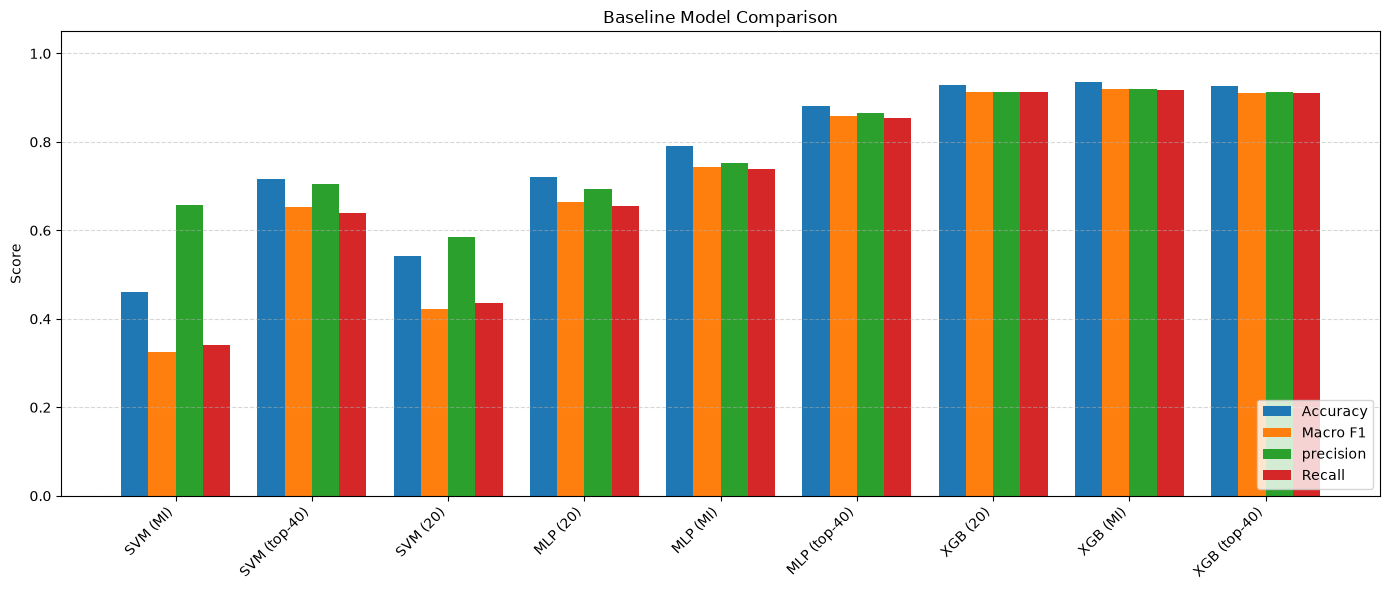


=== GridSearch Models ===
                        Accuracy  Macro F1  precision    Recall  Prediction runtime  GridSearch runtime
SVM (GridSearchCV)      0.791787  0.755507   0.779381  0.740813               5.110             308.988
MLP (GridSearchCV)      0.896183  0.874273   0.880772  0.868760               0.092            5331.364
XGBoost (GridSearchCV)  0.927704  0.912456   0.913732  0.911403               0.106             715.183


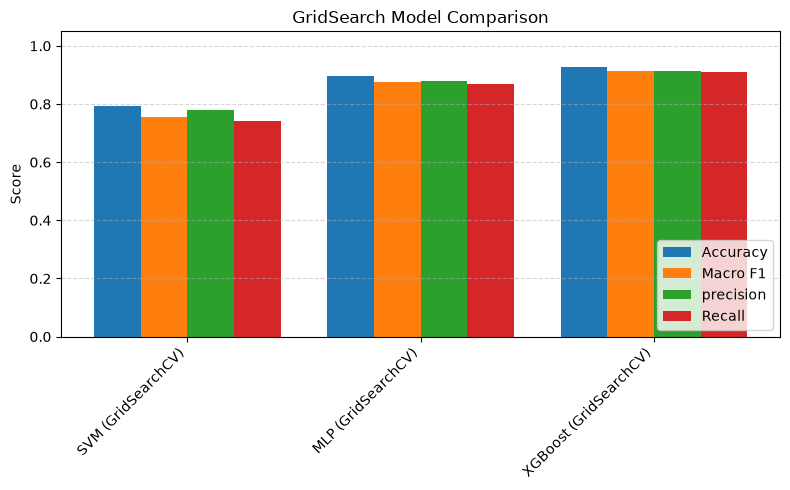

In [29]:
df = pd.DataFrame(RESULTS).T
df = df.astype(float)

df_baseline = df[df['GridSearch runtime'].isna()].drop(columns=['GridSearch runtime'])
df_gridsearch = df[df['Training runtime'].isna()].drop(columns=['Training runtime'])

print("=== Baseline Models ===")
print(df_baseline.to_string())

# ── Baseline Plot ─────────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Macro F1', 'precision', 'Recall']
x = np.arange(len(df_baseline))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_baseline[metric], width, label=metric)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_baseline.index, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── GridSearch Plot ───────────────────────────────────────────────────────────
print("\n=== GridSearch Models ===")
print(df_gridsearch.to_string())

x = np.arange(len(df_gridsearch))

fig, ax = plt.subplots(figsize=(8, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_gridsearch[metric], width, label=metric)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_gridsearch.index, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('GridSearch Model Comparison')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()